In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score
)

In [2]:
X, y = make_classification(
    n_samples=2000,        # Total number of samples
    n_features=10,         # Number of features
    n_informative=6,       # Number of informative features
    n_redundant=2,         # Number of redundant features
    n_classes=2,           # Binary classification (0 and 1)
    weights=[0.7, 0.3],    # Class imbalance (70% class 0, 30% class 1)
    random_state=42
)

print("Dataset Shape:", X.shape)
print("Class Distribution:", np.bincount(y))
#Make Dataframe
df = pd.DataFrame(X, columns=[f"Feature{i}" for i in range(X.shape[1])])
df["Target"]=y

Dataset Shape: (2000, 10)
Class Distribution: [1396  604]


In [3]:
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(X.shape[1])])
df['Target'] = y
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
0,-0.527985,2.502247,0.695293,-1.795216,-1.116564,-1.533083,-2.463545,1.197423,-1.900653,3.487929,0
1,-0.969457,-0.027843,0.491814,-0.904605,0.095751,1.047343,-0.838283,-0.857172,-0.848319,0.039613,0
2,-0.233425,-1.991787,-0.457817,-0.407070,-2.221362,-2.598014,0.857989,-0.579129,-1.251154,0.165376,0
3,-1.746842,1.005994,-1.276618,-2.529162,-1.537575,-2.303886,-0.133311,-0.748383,0.509019,2.254463,0
4,-1.297131,-1.451861,1.791782,-0.512722,-0.622481,-1.066218,-1.250867,-0.000132,-0.928541,0.423256,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    stratify=y          # Important for imbalanced data
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1500, 10)
Test set size: (500, 10)


In [5]:
model = DecisionTreeClassifier(
    criterion='gini',           # ← Using Gini Impurity
    max_depth=5,                # TODO: Students - Try different values (3, 5, 7, 10)
    min_samples_split=20,       # TODO: Students - Experiment with this
    min_samples_leaf=10,        # TODO: Students - Experiment with this
    class_weight='balanced',    # Helps with class imbalance
    random_state=42
)


In [6]:

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [7]:

y_pred = model.predict(X_test)

# Bonus (Optional): Get prediction probabilities
y_proba = model.predict_proba(X_test)[:, 1]

In [8]:
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)

# TODO: Print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# TODO: Print Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# TODO: Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


MODEL EVALUATION RESULTS
Accuracy: 0.8940

Confusion Matrix:
[[312  37]
 [ 16 135]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.89      0.92       349
     Class 1       0.78      0.89      0.84       151

    accuracy                           0.89       500
   macro avg       0.87      0.89      0.88       500
weighted avg       0.90      0.89      0.90       500



In [9]:
feature_importance = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(X.shape[1])],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head())


Top 5 Important Features:
     Feature  Importance
6  Feature_6    0.491779
4  Feature_4    0.300867
5  Feature_5    0.074312
0  Feature_0    0.057153
9  Feature_9    0.030765


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create synthetic binary classification data
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.7, 0.3],      # Class imbalance
    random_state=42
)

print("Dataset Shape:", X.shape)
print("Class Distribution:", np.bincount(y))
#Student's Task

#Make Dataframe


#Print first 5 rows
print("\nFirst 5 rows:")

Dataset Shape: (2000, 10)
Class Distribution: [1396  604]

First 5 rows:


In [11]:
# ============================================================
# STEP 2: Split Data into Training and Testing Sets (SOLUTION)
# ============================================================

#Student's Task
#Split the Data in Training and Testing Sets

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1500, 10)
Test set size: (500, 10)


In [12]:
model = DecisionTreeClassifier(
    
)

print("Model Parameters:")
print(model.get_params())

Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [13]:

model.fit(X_train, y_train)

print("Model training completed!")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model training completed!
Tree depth: 16
Number of leaves: 97


In [16]:

#Student's Task: Calculate the predictions and probabilities
y_prob = model.predict_proba(X_test)
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])

First 10 Predictions: [1 1 0 1 1 1 1 1 0 0]
First 10 Probabilities: [[1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [17]:

print("\n" + "="*55)
print("     BINARY CLASSIFICATION (Entropy) - RESULTS")
print("="*55)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


     BINARY CLASSIFICATION (Entropy) - RESULTS

Accuracy: 0.8940

Confusion Matrix:
[[312  37]
 [ 16 135]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.89      0.92       349
     Class 1       0.78      0.89      0.84       151

    accuracy                           0.89       500
   macro avg       0.87      0.89      0.88       500
weighted avg       0.90      0.89      0.90       500




Top Feature Importances (Entropy-based):
     Feature  Importance
6  Feature_6    0.353646
4  Feature_4    0.300043
0  Feature_0    0.069211
5  Feature_5    0.067788
8  Feature_8    0.059218
1  Feature_1    0.043717
9  Feature_9    0.030263
7  Feature_7    0.029470
2  Feature_2    0.023429
3  Feature_3    0.023215


C:\Users\pothu\AppData\Local\Temp\ipykernel_11560\2371017358.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


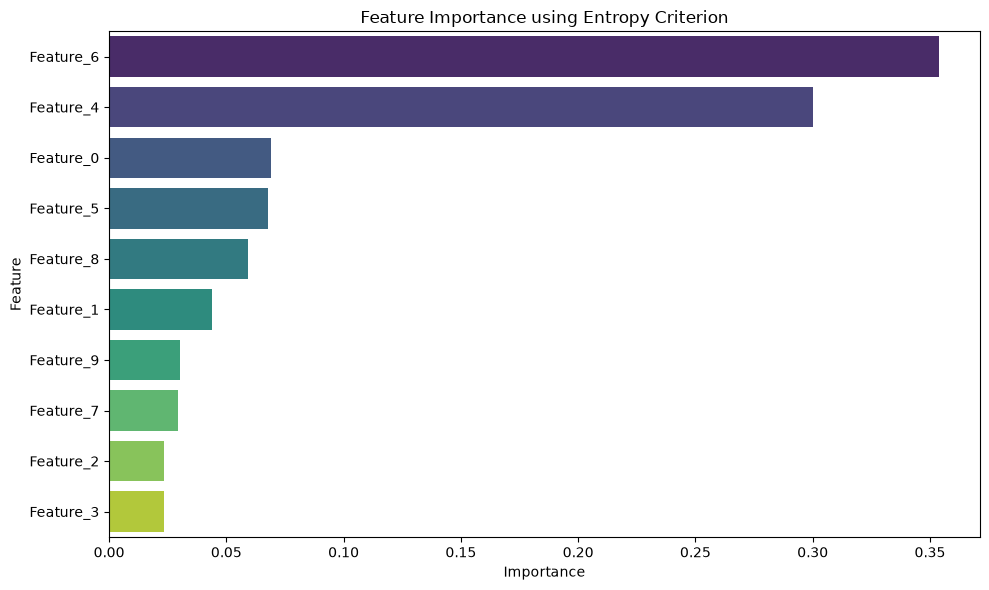

In [18]:
feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Feature Importances (Entropy-based):")
print(importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance using Entropy Criterion')
plt.tight_layout()
plt.show()

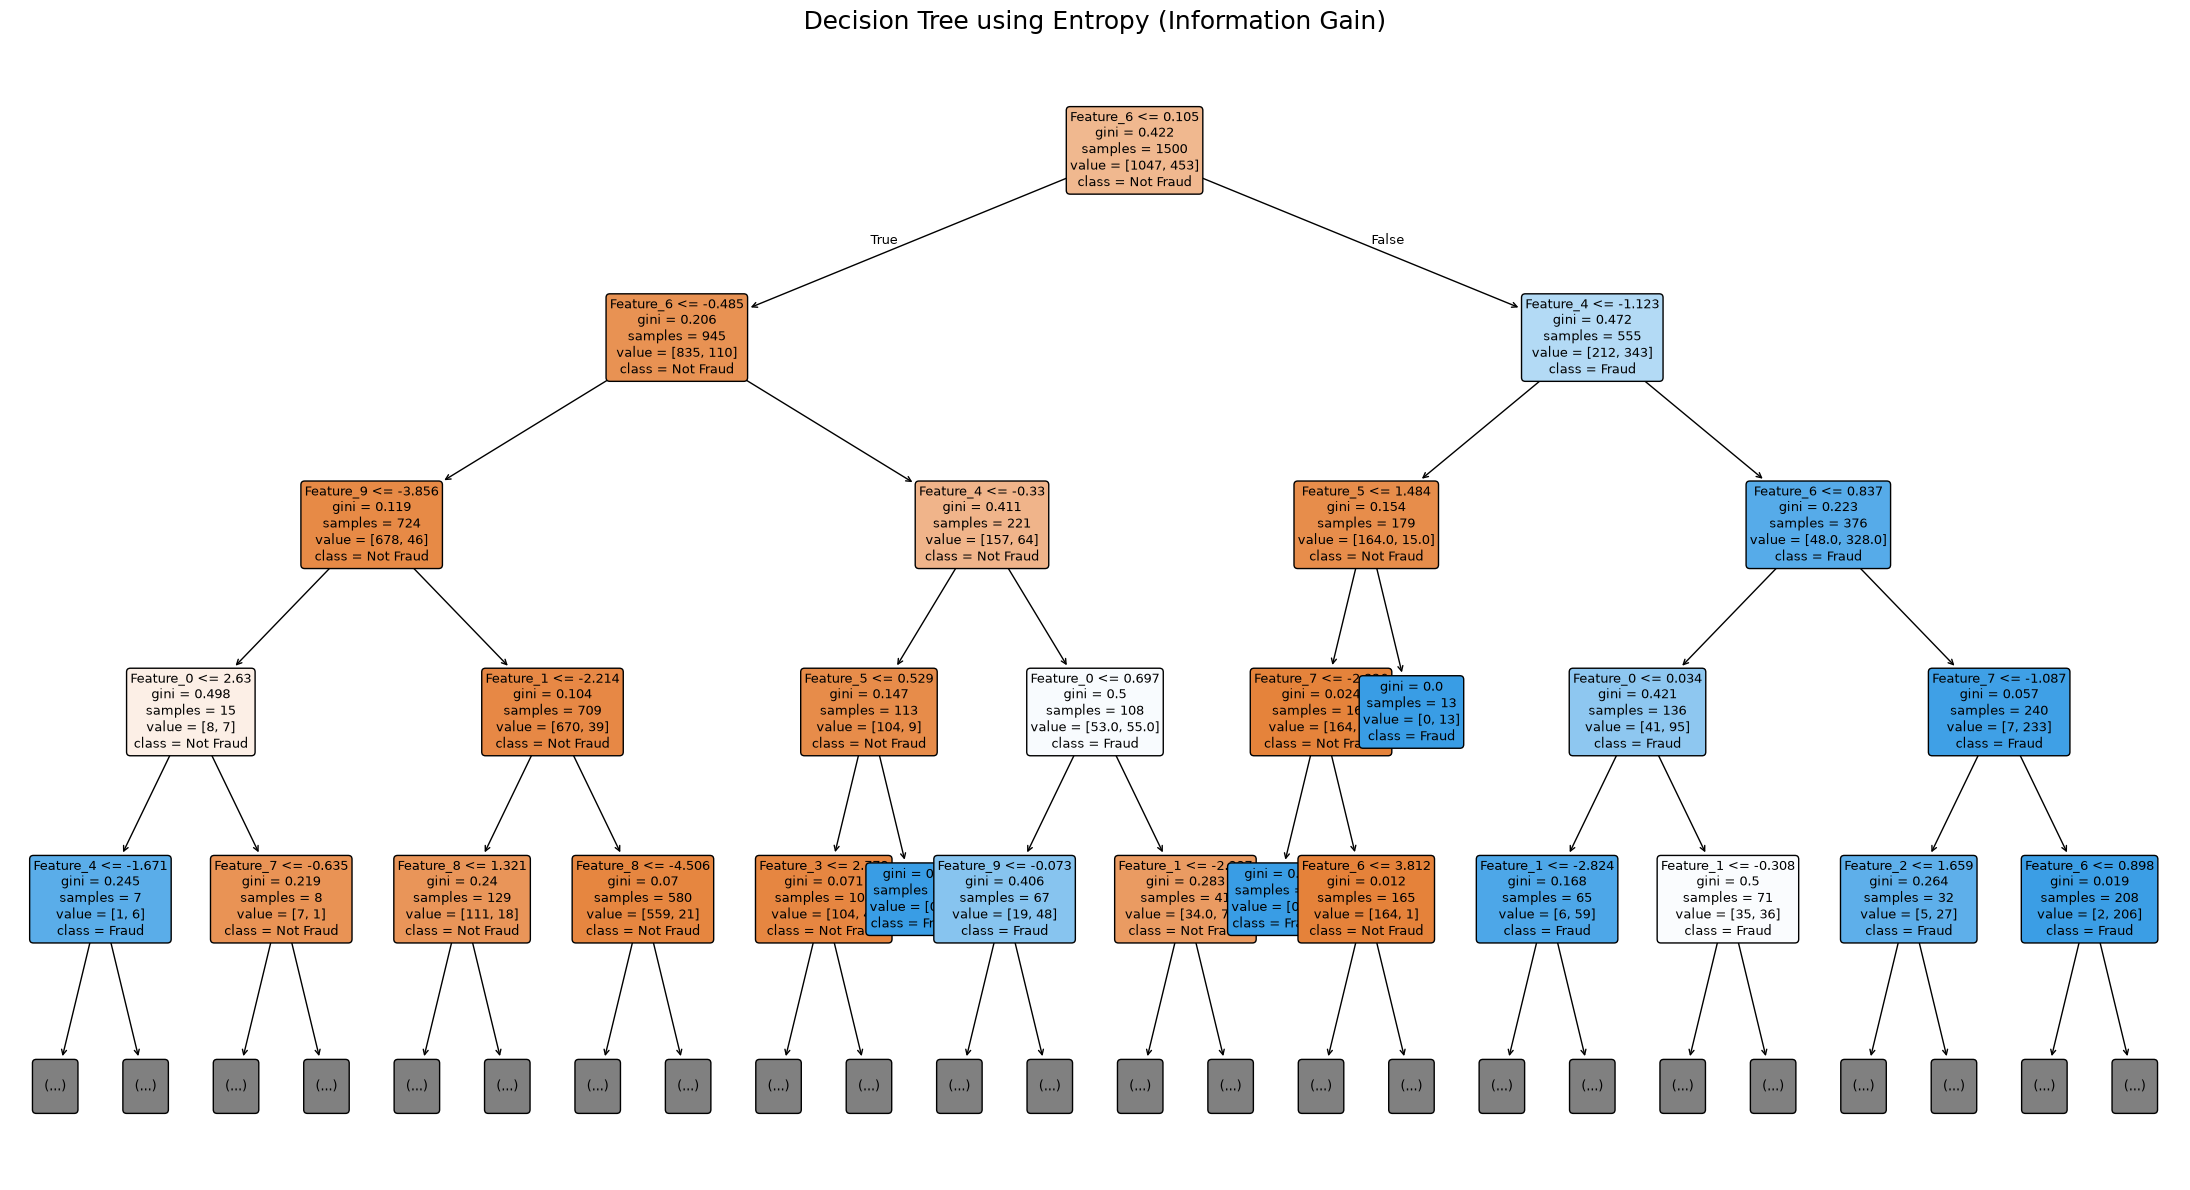

In [19]:

plt.figure(figsize=(22, 12))

plot_tree(
    model,
    feature_names=[f'Feature_{i}' for i in range(X.shape[1])],
    class_names=['Not Fraud', 'Fraud'],   # Change according to your problem
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4                          # You can increase this if tree is small
)

plt.title("Decision Tree using Entropy (Information Gain)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()